In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [17]:
macro_path = './output/ccar_macro_data_quarterly.csv'
df_macro = pd.read_csv(macro_path)
df_macro['DATE'] = pd.to_datetime(df_macro['DATE'])
df_macro.set_index('DATE', inplace=True)
df_macro.index = df_macro.index.to_period('Q')
print(df_macro.describe())

       Unemployment_Rate      Real_GDP  BBB_Spread  VIX_Volatility_Index  \
count         104.000000    104.000000  104.000000            104.000000   
mean            5.640545  18273.150202    1.980944             19.834158   
std             1.936582   2847.680659    0.997186              7.394865   
min             3.533333  13878.147000    0.994030             10.307937   
25%             4.166667  16319.276250    1.321654             14.466469   
50%             5.016667  17576.126000    1.751620             17.872615   
75%             6.208333  20463.450500    2.280861             24.013756   
max            13.000000  24111.830000    7.030462             58.604687   

       10Y_Treasury_Yield  3M_Treasury_Rate  Prime_Rate  CPI_Inflation  \
count          104.000000        104.000000  104.000000     104.000000   
mean             3.322854          1.889647    5.102782     233.471003   
std              1.285874          1.933953    2.012014      41.567073   
min              0.

In [18]:
co_path = './output/Fed_CO.csv' 
dr_path = './output/Fed_DR.csv'

df_co = pd.read_csv(co_path)
df_dr = pd.read_csv(dr_path)

df_co['Quarter_dt'] = pd.to_datetime(df_co['Quarter_dt'])
df_co.set_index('Quarter_dt', inplace=True)
df_co.index = df_co.index.to_period('Q')

df_dr['Quarter_dt'] = pd.to_datetime(df_dr['Quarter_dt'])
df_dr.set_index('Quarter_dt', inplace=True)
df_dr.index = df_dr.index.to_period('Q')

df_lgd = df_co.join(df_dr, how='inner')
print(df_lgd.describe())

       Wholesale_Proxy_NCO  Retail_Proxy_NCO  Wholesale_Proxy_DR  \
count           103.000000        103.000000          103.000000   
mean              0.006801          0.044142            0.016971   
std               0.006228          0.018847            0.010495   
min               0.001000          0.015600            0.005800   
25%               0.002700          0.034400            0.010150   
50%               0.004300          0.038600            0.012500   
75%               0.008100          0.050800            0.021300   
max               0.026700          0.106400            0.045400   

       Retail_Proxy_DR  
count       103.000000  
mean          0.033783  
std           0.012476  
min           0.014400  
25%           0.023900  
50%           0.030300  
75%           0.043450  
max           0.068700  


In [23]:
# Calculate Wholesale LGD (CO / DR)
zero_dr_count = (df_lgd['Wholesale_Proxy_DR'] == 0).sum()
print(zero_dr_count)
df_lgd['Wholesale_LGD'] = df_lgd['Wholesale_Proxy_NCO'] / df_lgd['Wholesale_Proxy_DR']
nan_count = df_lgd['Wholesale_LGD'].isna().sum()
print(nan_count)
print(df_lgd['Wholesale_LGD'])

0
0
Quarter_dt
2000Q1    0.308901
2000Q2    0.336538
2000Q3    0.325688
2000Q4    0.413502
2001Q1    0.428571
            ...   
2024Q3    0.522936
2024Q4    0.416667
2025Q1    0.474576
2025Q2    0.491525
2025Q3    0.464000
Freq: Q-DEC, Name: Wholesale_LGD, Length: 103, dtype: float64


In [24]:
df_model = df_lgd[['Wholesale_LGD']].join(df_macro, how='inner')
print(df_model.head())

        Wholesale_LGD  Unemployment_Rate   Real_GDP  BBB_Spread  \
2000Q1       0.308901           4.033333  13878.147    1.609077   
2000Q2       0.336538           3.933333  14130.908    2.139231   
2000Q3       0.325688           4.000000  14145.312    2.151515   
2000Q4       0.413502           3.900000  14229.765    2.496923   
2001Q1       0.428571           4.233333  14183.120    2.422154   

        VIX_Volatility_Index  10Y_Treasury_Yield  3M_Treasury_Rate  \
2000Q1             23.150317            6.468413          5.520000   
2000Q2             24.923968            6.184921          5.713333   
2000Q3             19.169048            5.889841          6.016667   
2000Q4             26.016667            5.570645          6.016667   
2001Q1             25.726452            5.044194          4.816667   

        Prime_Rate  CPI_Inflation  Real_Disposable_Income  Nominal_GDP  \
2000Q1    8.694444     170.100000             9833.933333    10002.179   
2000Q2    9.250000     171.4

In [25]:
candidate_macros = [
    'Real_GDP_Growth', 'Nominal_GDP_Growth', 'BBB_Spread', 
    '10Y_Treasury_Yield', 'Corp_Profits_YoY', 'HPI_YoY', 
    'Stock_Market_Return', 'VIX_Volatility_Index', 'Unemployment_Rate'
]
lags_to_test = [1, 2, 3, 4]

for lag in lags_to_test:
    df_model[f'LGD_Lag{lag}'] = df_model['Wholesale_LGD'].shift(lag)

for macro in candidate_macros:
    if macro in df_model.columns:  
        for lag in lags_to_test:
            col_name = f'{macro}_Lag{lag}'
            df_model[col_name] = df_model[macro].shift(lag)

df_model.dropna(inplace=True)
df_model.to_csv('./output/wholesale_lgd_model_candidates.csv')

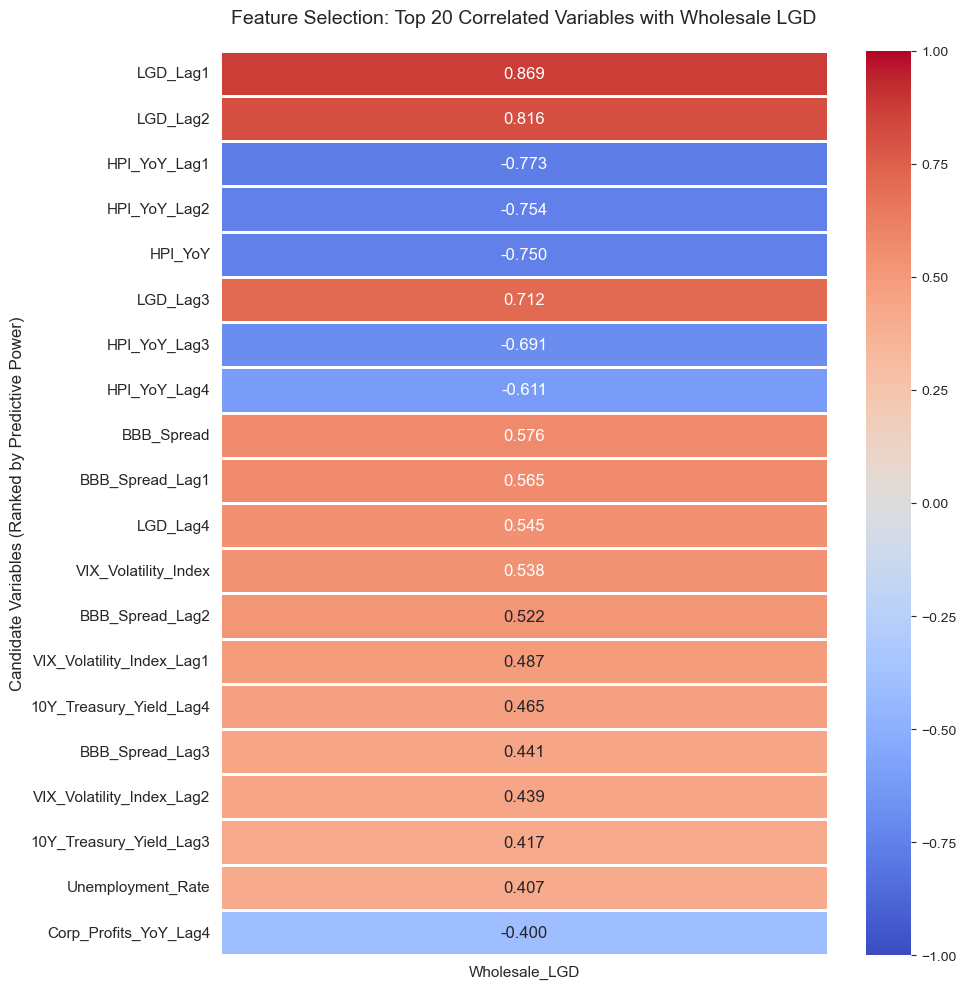

In [26]:
plt.figure(figsize=(10, 10))

target = 'Wholesale_LGD'

corr_with_lgd = df_model.corr()[[target]].drop(target)
corr_with_lgd['Absolute_Corr'] = corr_with_lgd[target].abs()
corr_with_lgd_sorted = corr_with_lgd.sort_values(by='Absolute_Corr', ascending=False)
corr_with_lgd_sorted.drop(columns=['Absolute_Corr'], inplace=True)

top_20_features = corr_with_lgd_sorted.head(20)

sns.heatmap(top_20_features, annot=True, annot_kws={"size": 12}, 
            cmap='coolwarm', fmt=".3f", linewidths=1, vmin=-1, vmax=1)

plt.title('Feature Selection: Top 20 Correlated Variables with Wholesale LGD', fontsize=14, pad=20)
plt.ylabel('Candidate Variables (Ranked by Predictive Power)', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.savefig('./output/chart_lgd_wholesale_feature_selection.png', dpi=600, bbox_inches='tight')
plt.show()